In [8]:
from connectivity_matrix_functions import find_poly, create_shp_index, calc_connectivity_lh, write_to_file, plot_conn_mat, plot_conn_mat_norm, plot_conn_mat_norm_noAN, plot_conn_mat_normcol_noAN, plot_conn_mat_diff
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import FormatStrFormatter
import cartopy
import cartopy.crs as ccrs
import time
import datetime
from datetime import datetime, timedelta
from netCDF4 import Dataset

In [9]:
input_particle_file_SLmon = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_SL_uniform_Cop_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_Indiamon = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_India_uniform_Cop_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_Bangmon = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Bang_uniform_Cop_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_Myanmon = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Myan_uniform_Cop_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_Thaimon = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Thai_uniform_Cop_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_Indomon = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Indonesia_uniform_Cop_daily_Jun2018-Sept2019_monsoon.nc'

In [10]:
input_particle_file_SLmonR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_SL_uniform_ROMS_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_IndiamonR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_India_uniform_ROMS_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_BangmonR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Bang_uniform_ROMS_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_MyanmonR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Myan_uniform_ROMS_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_ThaimonR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Thai_uniform_ROMS_daily_Jun2018-Sept2019_monsoon.nc'
input_particle_file_IndomonR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Indonesia_uniform_ROMS_daily_Jun2018-Sept2019_monsoon.nc'

In [11]:
input_particle_file_SLpost = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_SL_uniform_Cop_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_Indiapost = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_India_uniform_Cop_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_Bangpost = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Bang_uniform_Cop_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_Myanpost = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Myan_uniform_Cop_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_Thaipost = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Thai_uniform_Cop_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_Indopost = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Indonesia_uniform_Cop_daily_Oct2018-Sept2019_postmonsoon.nc'

In [12]:
input_particle_file_SLpostR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_SL_uniform_ROMS_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_IndiapostR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_India_uniform_ROMS_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_BangpostR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Bang_uniform_ROMS_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_MyanpostR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Myan_uniform_ROMS_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_ThaipostR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Thai_uniform_ROMS_daily_Oct2018-Sept2019_postmonsoon.nc'
input_particle_file_IndopostR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Indonesia_uniform_ROMS_daily_Oct2018-Sept2019_postmonsoon.nc'

In [13]:
input_particle_file_SLpre = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_SL_uniform_Cop_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_Indiapre = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_India_uniform_Cop_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_Bangpre = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Bang_uniform_Cop_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_Myanpre = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Myan_uniform_Cop_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_Thaipre = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Thai_uniform_Cop_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_Indopre = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Indonesia_uniform_Cop_daily_Feb-Sept2019_premonsoon.nc'

In [14]:
input_particle_file_SLpreR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_SL_uniform_ROMS_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_IndiapreR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_India_uniform_ROMS_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_BangpreR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Bang_uniform_ROMS_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_MyanpreR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Myan_uniform_ROMS_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_ThaipreR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Thai_uniform_ROMS_daily_Feb-Sept2019_premonsoon.nc'
input_particle_file_IndopreR = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/BoB_Indonesia_uniform_ROMS_daily_Feb-Sept2019_premonsoon.nc'

In [25]:
def calc_when_escaped(season, input_particle_file, polygons_filename, polygons_SEW_filename,
                      end_polygons, end_polygons_idx):

    if season == "monsoon":
        start_date = np.datetime64(datetime.strptime('2018-06-01T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
        end_date = np.datetime64(datetime.strptime('2018-09-30T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
    elif season =="postmonsoon":
        start_date = np.datetime64(datetime.strptime('2018-10-01T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
        end_date = np.datetime64(datetime.strptime('2019-01-31T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
    elif season == "premonsoon":
        start_date = np.datetime64(datetime.strptime('2019-02-01T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
        end_date = np.datetime64(datetime.strptime('2019-05-31T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))        
    else:
        print("Please enter season in following format: 'monsoon', 'postmonsoon' or 'premonsoon'")    
        
    trajDS = xr.load_dataset(input_particle_file)

    week = timedelta(weeks=1)
    week64 = np.timedelta64(week)
    countSE_1week = 0
    countSE_season = 0
    countSE_later = 0
    countS_1week = 0
    countS_season = 0
    countS_later = 0
    countSW_1week = 0
    countSW_season = 0
    countSW_later = 0

    polygons_gpd = gpd.read_file(polygons_filename)
    polygons_SEW_gpd = gpd.read_file(polygons_SEW_filename)
    n_end_polygons = len(polygons_SEW_gpd['geometry'][:])

    for iparticle in range( trajDS.dims['traj'] ):
        if not any(trajDS.variables['beached'][iparticle,:]==1):
#             print('iparticle: ', iparticle)
            lons = trajDS['lon'].isel(traj=iparticle).values
            lats = trajDS['lat'].isel(traj=iparticle).values
            times = trajDS['time'].isel(traj=iparticle).values
#             print(np.shape(times))
            #times = trajDS.variables['time'].values

            for itime in range(len(lons)-1):
                if not(np.isnan(lons[itime])) and np.isnan(lons[itime+1]):
                    end_polygon_id = find_poly(
                                        polygons = end_polygons,
                                        polyind = end_polygons_idx,
                                        coords = (lons[itime],lats[itime])
                    )

                    if end_polygon_id == 0:
                        if times[itime]<times[0]+week64:
                            countS_1week += 1
                        elif times[itime]<=end_date:
                            countS_season += 1
                        elif times[itime]>end_date:
                            countS_later += 1
                    elif end_polygon_id == 1:
                        if times[itime]<times[0]+week64:
                            countSW_1week += 1
                        elif times[itime]<=end_date:
                            countSW_season += 1
                        elif times[itime]>end_date:
                            countSW_later += 1
                    elif end_polygon_id == 2:
                        if times[itime]<times[0]+week64:
                            countSE_1week += 1
                        elif times[itime]<=end_date:
                            countSE_season += 1
                        elif times[itime]>end_date:
                            countSE_later += 1


            if end_polygon_id is None:
                continue

#             print('end_polygon_id: ', end_polygon_id)

    print("countSW_1week: ", countSW_1week)
    print("countSW_season: ", countSW_season)
    print("countSW_later: ", countSW_later)
    print("countS_1week: ", countS_1week)
    print("countS_season: ", countS_season)
    print("countS_later: ", countS_later)
    print("countSE_1week: ", countSE_1week)
    print("countSE_season: ", countSE_season)
    print("countSE_later: ", countSE_later)

# this code cannot calc how many particles are left afloat as the loop doesn't go to the last timestep
# This also means that any particles that escape ON the last timestep will not be counted!!

    return countSE_1week, countSE_season, countSE_later, countS_1week, countS_season, countS_later, countSW_1week, countSW_season, countSW_later

In [26]:
polygons_filename = "/gpfs/home/rpe16nbu/projects/ocpp_mo1/misc/polygons_BoB6_start.geojson"
polygons_SEW_filename = "/gpfs/home/rpe16nbu/projects/ocpp_mo1/misc/polygons_escaped_particles.geojson"
polygons, polygons_idx, polygons_names = create_shp_index(polygons_filename, 'name')
polygons_SEW, polygons_SEW_idx, polygons_SEW_names = create_shp_index(polygons_SEW_filename, 'name') # SEW = SouthEastWest

File /gpfs/home/rpe16nbu/projects/ocpp_mo1/misc/polygons_BoB6_start.geojson  has  6  polygons
File /gpfs/home/rpe16nbu/projects/ocpp_mo1/misc/polygons_escaped_particles.geojson  has  3  polygons


In [27]:
(countSE_1week_SLmon, countSE_season_SLmon, countSE_later_SLmon, countS_1week_SLmon, countS_season_SLmon, 
 countS_later_SLmon, countSW_1week_SLmon, countSW_season_SLmon, countSW_later_SLmon) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_SLmon, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  1111
countS_1week:  0
countS_season:  0
countS_later:  308
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [28]:
(countSE_1week_Indiamon, countSE_season_Indiamon, countSE_later_Indiamon, countS_1week_Indiamon, countS_season_Indiamon,
    countS_later_Indiamon, count_1week_Indiamon, countSW_season_Indiamon, countSW_later_Indiamon) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_Indiamon, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  53
countSW_season:  1
countSW_later:  2074
countS_1week:  0
countS_season:  0
countS_later:  174
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [29]:
(countSE_1week_Bangmon, countSE_season_Bangmon, countSE_later_Bangmon, countS_1week_Bangmon, countS_season_Bangmon, 
 countS_later_Bangmon, countSW_1week_Bangmon, countSW_season_Bangmon, countSW_later_Bangmon) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_Bangmon, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  42
countS_1week:  0
countS_season:  0
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  1


In [30]:
(countSE_1week_Myanmon, countSE_season_Myanmon, countSE_later_Myanmon, countS_1week_Myanmon, countS_season_Myanmon, 
 countS_later_Myanmon, countSW_1week_Myanmon, countSW_season_Myanmon, countSW_later_Myanmon) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_Myanmon, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  220
countS_1week:  0
countS_season:  0
countS_later:  30
countSE_1week:  0
countSE_season:  0
countSE_later:  1


In [31]:
(countSE_1week_Thaimon, countSE_season_Thaimon, countSE_later_Thaimon, countS_1week_Thaimon, countS_season_Thaimon, 
 countS_later_Thaimon, countSW_1week_Thaimon, countSW_season_Thaimon, countSW_later_Thaimon) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_Thaimon, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  31
countS_1week:  0
countS_season:  0
countS_later:  19
countSE_1week:  805
countSE_season:  57
countSE_later:  12


In [32]:
(countSE_1week_Indomon, countSE_season_Indomon, countSE_later_Indomon, countS_1week_Indomon, countS_season_Indomon, 
 countS_later_Indomon, countSW_1week_Indomon, countSW_season_Indomon, countSW_later_Indomon) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_Indomon, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  238
countS_1week:  193
countS_season:  256
countS_later:  320
countSE_1week:  106
countSE_season:  1900
countSE_later:  77


In [33]:
(countSE_1week_SLpost, countSE_season_SLpost, countSE_later_SLpost, countS_1week_SLpost, countS_season_SLpost, 
 countS_later_SLpost, countSW_1week_SLpost, countSW_season_SLpost, countSW_later_SLpost) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_SLpost, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  303
countSW_season:  4851
countSW_later:  693
countS_1week:  8
countS_season:  171
countS_later:  6
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [34]:
(countSE_1week_Indiapost, countSE_season_Indiapost, countSE_later_Indiapost, countS_1week_Indiapost, countS_season_Indiapost, 
 countS_later_Indiapost, countSW_1week_Indiapost, countSW_season_Indiapost, countSW_later_Indiapost) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_Indiapost, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  1060
countSW_season:  2267
countSW_later:  77
countS_1week:  0
countS_season:  32
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [35]:
(countSE_1week_Bangpost, countSE_season_Bangpost, countSE_later_Bangpost, countS_1week_Bangpost, countS_season_Bangpost, 
 countS_later_Bangpost, countSW_1week_Bangpost, countSW_season_Bangpost, countSW_later_Bangpost) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_Bangpost, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  49
countSW_later:  11
countS_1week:  0
countS_season:  0
countS_later:  2
countSE_1week:  0
countSE_season:  0
countSE_later:  2


In [36]:
(countSE_1week_Myanpost, countSE_season_Myanpost, countSE_later_Myanpost, countS_1week_Myanpost, countS_season_Myanpost, 
 countS_later_Myanpost, countSW_1week_Myanpost, countSW_season_Myanpost, countSW_later_Myanpost) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_Myanpost, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  136
countSW_later:  1108
countS_1week:  0
countS_season:  84
countS_later:  943
countSE_1week:  0
countSE_season:  0
countSE_later:  147


In [37]:
(countSE_1week_Thaipost, countSE_season_Thaipost, countSE_later_Thaipost, countS_1week_Thaipost, countS_season_Thaipost, 
 countS_later_Thaipost, countSW_1week_Thaipost, countSW_season_Thaipost, countSW_later_Thaipost) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_Thaipost, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  1
countSW_later:  648
countS_1week:  0
countS_season:  204
countS_later:  464
countSE_1week:  130
countSE_season:  42
countSE_later:  43


In [38]:
(countSE_1week_Indopost, countSE_season_Indopost, countSE_later_Indopost, countS_1week_Indopost, countS_season_Indopost, 
 countS_later_Indopost, countSW_1week_Indopost, countSW_season_Indopost, countSW_later_Indopost) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_Indopost, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  2
countSW_later:  395
countS_1week:  447
countS_season:  1272
countS_later:  548
countSE_1week:  203
countSE_season:  115
countSE_later:  159


In [39]:
(countSE_1week_SLpre, countSE_season_SLpre, countSE_later_SLpre, countS_1week_SLpre, countS_season_SLpre, 
 countS_later_SLpre, countSW_1week_SLpre, countSW_season_SLpre, countSW_later_SLpre) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_SLpre, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  63
countSW_season:  1138
countSW_later:  0
countS_1week:  2
countS_season:  119
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  6


In [40]:
(countSE_1week_Indiapre, countSE_season_Indiapre, countSE_later_Indiapre, countS_1week_Indiapre, countS_season_Indiapre, 
 countS_later_Indiapre, countSW_1week_Indiapre, countSW_season_Indiapre, countSW_later_Indiapre) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_Indiapre, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  322
countSW_season:  184
countSW_later:  0
countS_1week:  0
countS_season:  3
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [41]:
(countSE_1week_Bangpre, countSE_season_Bangpre, countSE_later_Bangpre, countS_1week_Bangpre, countS_season_Bangpre, 
 countS_later_Bangpre, countSW_1week_Bangpre, countSW_season_Bangpre, countSW_later_Bangpre) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_Bangpre, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  0
countS_1week:  0
countS_season:  0
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [42]:
(countSE_1week_Myanpre, countSE_season_Myanpre, countSE_later_Myanpre, countS_1week_Myanpre, countS_season_Myanpre, 
 countS_later_Myanpre, countSW_1week_Myanpre, countSW_season_Myanpre, countSW_later_Myanpre) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_Myanpre, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  0
countS_1week:  0
countS_season:  4
countS_later:  2
countSE_1week:  0
countSE_season:  112
countSE_later:  19


In [43]:
(countSE_1week_Thaipre, countSE_season_Thaipre, countSE_later_Thaipre, countS_1week_Thaipre, countS_season_Thaipre, 
 countS_later_Thaipre, countSW_1week_Thaipre, countSW_season_Thaipre, countSW_later_Thaipre) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_Thaipre, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  0
countS_1week:  0
countS_season:  38
countS_later:  10
countSE_1week:  373
countSE_season:  296
countSE_later:  46


In [44]:
(countSE_1week_Indopre, countSE_season_Indopre, countSE_later_Indopre, countS_1week_Indopre, countS_season_Indopre, 
 countS_later_Indopre, countSW_1week_Indopre, countSW_season_Indopre, countSW_later_Indopre) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_Indopre, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  0
countS_1week:  332
countS_season:  281
countS_later:  75
countSE_1week:  124
countSE_season:  984
countSE_later:  424


In [45]:
(countSE_1week_SLmonR, countSE_season_SLmonR, countSE_later_SLmonR, countS_1week_SLmonR, countS_season_SLmonR, 
 countS_later_SLmonR, countSW_1week_SLmonR, countSW_season_SLmonR, countSW_later_SLmonR) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_SLmonR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  488
countS_1week:  0
countS_season:  0
countS_later:  266
countSE_1week:  0
countSE_season:  2
countSE_later:  84


In [46]:
(countSE_1week_IndiamonR, countSE_season_IndiamonR, countSE_later_IndiamonR, countS_1week_IndiamonR, countS_season_IndiamonR, 
 countS_later_IndiamonR, countSW_1week_IndiamonR, countSW_season_IndiamonR, countSW_later_IndiamonR) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_IndiamonR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  14
countSW_season:  0
countSW_later:  196
countS_1week:  0
countS_season:  0
countS_later:  77
countSE_1week:  0
countSE_season:  0
countSE_later:  1


In [47]:
(countSE_1week_BangmonR, countSE_season_BangmonR, countSE_later_BangmonR, countS_1week_BangmonR, countS_season_BangmonR, 
 countS_later_BangmonR, countSW_1week_BangmonR, countSW_season_BangmonR, countSW_later_BangmonR) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_BangmonR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  0
countS_1week:  0
countS_season:  0
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [48]:
(countSE_1week_MyanmonR, countSE_season_MyanmonR, countSE_later_MyanmonR, countS_1week_MyanmonR, countS_season_MyanmonR, 
 countS_later_MyanmonR, countSW_1week_MyanmonR, countSW_season_MyanmonR, countSW_later_MyanmonR) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_MyanmonR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  26
countS_1week:  0
countS_season:  0
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  1


In [49]:
(countSE_1week_ThaimonR, countSE_season_ThaimonR, countSE_later_ThaimonR, countS_1week_ThaimonR, countS_season_ThaimonR, 
 countS_later_ThaimonR, countSW_1week_ThaimonR, countSW_season_ThaimonR, countSW_later_ThaimonR) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_ThaimonR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  11
countS_1week:  0
countS_season:  0
countS_later:  4
countSE_1week:  273
countSE_season:  7
countSE_later:  14


In [50]:
(countSE_1week_IndomonR, countSE_season_IndomonR, countSE_later_IndomonR, countS_1week_IndomonR, countS_season_IndomonR, 
 countS_later_IndomonR, countSW_1week_IndomonR, countSW_season_IndomonR, countSW_later_IndomonR) = calc_when_escaped(
    season="monsoon", input_particle_file=input_particle_file_IndomonR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  104
countS_1week:  486
countS_season:  333
countS_later:  97
countSE_1week:  36
countSE_season:  669
countSE_later:  61


In [51]:
(countSE_1week_SLpostR, countSE_season_SLpostR, countSE_later_SLpostR, countS_1week_SLpostR, countS_season_SLpostR, 
 countS_later_SLpostR, countSW_1week_SLpostR, countSW_season_SLpostR, countSW_later_SLpostR) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_SLpostR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  212
countSW_season:  2883
countSW_later:  482
countS_1week:  30
countS_season:  480
countS_later:  3
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [52]:
(countSE_1week_IndiapostR, countSE_season_IndiapostR, countSE_later_IndiapostR, countS_1week_IndiapostR, countS_season_IndiapostR, 
 countS_later_IndiapostR, countSW_1week_IndiapostR, countSW_season_IndiapostR, countSW_later_IndiapostR) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_IndiapostR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  647
countSW_season:  577
countSW_later:  16
countS_1week:  0
countS_season:  14
countS_later:  10
countSE_1week:  0
countSE_season:  0
countSE_later:  1


In [53]:
(countSE_1week_BangpostR, countSE_season_BangpostR, countSE_later_BangpostR, countS_1week_BangpostR, countS_season_BangpostR, 
 countS_later_BangpostR, countSW_1week_BangpostR, countSW_season_BangpostR, countSW_later_BangpostR) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_BangpostR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  9
countSW_later:  13
countS_1week:  0
countS_season:  0
countS_later:  22
countSE_1week:  0
countSE_season:  0
countSE_later:  9


In [54]:
(countSE_1week_MyanpostR, countSE_season_MyanpostR, countSE_later_MyanpostR, countS_1week_MyanpostR, countS_season_MyanpostR, 
 countS_later_MyanpostR, countSW_1week_MyanpostR, countSW_season_MyanpostR, countSW_later_MyanpostR) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_MyanpostR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  39
countSW_later:  646
countS_1week:  0
countS_season:  18
countS_later:  166
countSE_1week:  0
countSE_season:  0
countSE_later:  86


In [55]:
(countSE_1week_ThaipostR, countSE_season_ThaipostR, countSE_later_ThaipostR, countS_1week_ThaipostR, countS_season_ThaipostR, 
 countS_later_ThaipostR, countSW_1week_ThaipostR, countSW_season_ThaipostR, countSW_later_ThaipostR) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_ThaipostR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  10
countSW_later:  333
countS_1week:  0
countS_season:  81
countS_later:  95
countSE_1week:  92
countSE_season:  43
countSE_later:  24


In [56]:
(countSE_1week_IndopostR, countSE_season_IndopostR, countSE_later_IndopostR, countS_1week_IndopostR, countS_season_IndopostR, 
 countS_later_IndopostR, countSW_1week_IndopostR, countSW_season_IndopostR, countSW_later_IndopostR) = calc_when_escaped(
    season="postmonsoon", input_particle_file=input_particle_file_IndopostR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  42
countSW_later:  320
countS_1week:  494
countS_season:  331
countS_later:  165
countSE_1week:  183
countSE_season:  366
countSE_later:  31


In [57]:
(countSE_1week_SLpreR, countSE_season_SLpreR, countSE_later_SLpreR, countS_1week_SLpreR, countS_season_SLpreR, 
 countS_later_SLpreR, countSW_1week_SLpreR, countSW_season_SLpreR, countSW_later_SLpreR) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_SLpreR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  45
countSW_season:  897
countSW_later:  0
countS_1week:  3
countS_season:  42
countS_later:  68
countSE_1week:  0
countSE_season:  0
countSE_later:  12


In [58]:
(countSE_1week_IndiapreR, countSE_season_IndiapreR, countSE_later_IndiapreR, countS_1week_IndiapreR, countS_season_IndiapreR, 
 countS_later_IndiapreR, countSW_1week_IndiapreR, countSW_season_IndiapreR, countSW_later_IndiapreR) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_IndiapreR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  227
countSW_season:  71
countSW_later:  0
countS_1week:  0
countS_season:  4
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [59]:
(countSE_1week_BangpreR, countSE_season_BangpreR, countSE_later_BangpreR, countS_1week_BangpreR, countS_season_BangpreR, 
 countS_later_BangpreR, countSW_1week_BangpreR, countSW_season_BangpreR, countSW_later_BangpreR) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_BangpreR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  0
countS_1week:  0
countS_season:  0
countS_later:  0
countSE_1week:  0
countSE_season:  0
countSE_later:  0


In [60]:
(countSE_1week_MyanpreR, countSE_season_MyanpreR, countSE_later_MyanpreR, countS_1week_MyanpreR, countS_season_MyanpreR, 
 countS_later_MyanpreR, countSW_1week_MyanpreR, countSW_season_MyanpreR, countSW_later_MyanpreR) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_MyanpreR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  0
countSW_later:  0
countS_1week:  0
countS_season:  6
countS_later:  1
countSE_1week:  0
countSE_season:  107
countSE_later:  22


In [61]:
(countSE_1week_ThaipreR, countSE_season_ThaipreR, countSE_later_ThaipreR, countS_1week_ThaipreR, countS_season_ThaipreR, 
 countS_later_ThaipreR, countSW_1week_ThaipreR, countSW_season_ThaipreR, countSW_later_ThaipreR) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_ThaipreR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  10
countSW_later:  0
countS_1week:  0
countS_season:  5
countS_later:  3
countSE_1week:  207
countSE_season:  194
countSE_later:  54


In [62]:
(countSE_1week_IndopreR, countSE_season_IndopreR, countSE_later_IndopreR, countS_1week_IndopreR, countS_season_IndopreR, 
 countS_later_IndopreR, countSW_1week_IndopreR, countSW_season_IndopreR, countSW_later_IndopreR) = calc_when_escaped(
    season="premonsoon", input_particle_file=input_particle_file_IndopreR, polygons_filename=polygons_filename, polygons_SEW_filename=polygons_SEW_filename, end_polygons=polygons_SEW, end_polygons_idx=polygons_SEW_idx)


/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gpfs/home/rpe16nbu/.conda/envs/py3_parcels/lib/python3.9/site-packages/xarray/coding/times.py:242: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


countSW_1week:  0
countSW_season:  8
countSW_later:  0
countS_1week:  411
countS_season:  259
countS_later:  43
countSE_1week:  93
countSE_season:  361
countSE_later:  340


In [ ]:
def calc_when_beaches(season, input_particle_file):

    if season == "monsoon":
        start_date = np.datetime64(datetime.strptime('2018-06-01T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
        end_date = np.datetime64(datetime.strptime('2018-09-30T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
    elif season =="postmonsoon":
        start_date = np.datetime64(datetime.strptime('2018-10-01T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
        end_date = np.datetime64(datetime.strptime('2019-01-31T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
    elif season == "premonsoon":
        start_date = np.datetime64(datetime.strptime('2019-02-01T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))
        end_date = np.datetime64(datetime.strptime('2019-05-31T12:00:00.000000000', '%Y-%m-%dT%H:%M:%S.%f000'))        
    else:
        print("Please enter season in following format: 'monsoon', 'postmonsoon' or 'premonsoon'")    
        
    week = timedelta(weeks=1)
    week64 = np.timedelta64(week)
    count_beach_1week = 0
    count_beach_season = 0
    count_beach_later = 0
    count_escape_1week = 0
    count_escape_season = 0
    count_escape_later = 0
    count_still_afloat = 0

    trajDS = xr.load_dataset(input_particle_file)
#     times = trajDS.variables['time'].values 
    beached = trajDS.variables['beached'].values
#     lons = trajDS.variables['lon'].values

    for iparticle in range( trajDS.dims['traj'] ):
#     print('iparticle: ', iparticle)
        if any(trajDS.variables['beached'][iparticle,:]==1):
            lons = trajDS['lon'].isel(traj=iparticle).values
            lats = trajDS['lat'].isel(traj=iparticle).values
            times = trajDS['time'].isel(traj=iparticle).values
            for itime in range(trajDS.dims['obs']):
#                 print('itime:', itime)
#                 print('beached[iparticle,itime]:', beached[iparticle,itime])
                if beached[iparticle,itime]==1:
                    if times[itime]<times[0]+week64:
                        count_beach_1week += 1
                    elif times[itime]<=end_date:
                        count_beach_season += 1
                    elif times[itime]>end_date:
                        count_beach_later += 1
                else: 
                    continue
                            
    print('count_beach_1week: ', count_beach_1week)
    print('count_beach_season: ', count_beach_season)
    print('count_beach_later: ', count_beach_later)
    
    return count_beach_1week, count_beach_season, count_beach_later
    

In [ ]:
(count_beach_1week_SLmon, count_beach_season_SLmon, count_beach_later_SLmon) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_SLmon)


In [ ]:
(count_beach_1week_Indiamon, count_beach_season_Indiamon, count_beach_later_Indiamon) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_Indiamon)
    

In [ ]:
(count_beach_1week_Bangmon, count_beach_season_Bangmon, count_beach_later_Bangmon) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_Bangmon)
    

In [ ]:
(count_beach_1week_Myanmon, count_beach_season_Myanmon, count_beach_later_Myanmon) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_Myanmon)
    

In [ ]:
(count_beach_1week_Thaimon, count_beach_season_Thaimon, count_beach_later_Thaimon) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_Thaimon)
    

In [ ]:
(count_beach_1week_Indomon, count_beach_season_Indomon, count_beach_later_Indomon) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_Indomon)
    

In [ ]:
(count_beach_1week_SLpost, count_beach_season_SLpost, count_beach_later_SLpost) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_SLpost)
    

In [ ]:
(count_beach_1week_Indiapost, count_beach_season_Indiapost, count_beach_later_Indiapost) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_Indiapost)
    

In [ ]:
(count_beach_1week_Bangpost, count_beach_season_Bangpost, count_beach_later_Bangpost) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_Bangpost)
    

In [ ]:
(count_beach_1week_Myanpost, count_beach_season_Myanpost, count_beach_later_Myanpost) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_Myanpost)
    

In [ ]:
(count_beach_1week_Thaipost, count_beach_season_Thaipost, count_beach_later_Thaipost) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_Thaipost)
    

In [ ]:
(count_beach_1week_Indopost, count_beach_season_Indopost, count_beach_later_Indopost) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_Indopost)
    

In [ ]:
(count_beach_1week_SLpre, count_beach_season_SLpre, count_beach_later_SLpre) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_SLpre)
    

In [ ]:
(count_beach_1week_Indiapre, count_beach_season_Indiapre, count_beach_later_Indiapre) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_Indiapre)
    

In [ ]:
(count_beach_1week_Bangpre, count_beach_season_Bangpre, count_beach_later_Bangpre) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_Bangpre)
    

In [ ]:
(count_beach_1week_Myanpre, count_beach_season_Myanpre, count_beach_later_Myanpre) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_Myanpre)
    

In [ ]:
(count_beach_1week_Thaipre, count_beach_season_Thaipre, count_beach_later_Thaipre) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_Thaipre)
    

In [ ]:
(count_beach_1week_Indopre, count_beach_season_Indopre, count_beach_later_Indopre) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_Indopre)
    

In [ ]:
(count_beach_1week_SLmonR, count_beach_season_SLmonR, count_beach_later_SLmonR) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_SLmonR)
    

In [ ]:
(count_beach_1week_IndiamonR, count_beach_season_IndiamonR, count_beach_later_IndiamonR) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_IndiamonR)
    

In [ ]:
(count_beach_1week_BangmonR, count_beach_season_BangmonR, count_beach_later_BangmonR) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_BangmonR)
    

In [ ]:
(count_beach_1week_MyanmonR, count_beach_season_MyanmonR, count_beach_later_MyanmonR) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_MyanmonR)
    

In [ ]:
(count_beach_1week_ThaimonR, count_beach_season_ThaimonR, count_beach_later_ThaimonR) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_ThaimonR)
    

In [ ]:
(count_beach_1week_IndomonR, count_beach_season_IndomonR, count_beach_later_IndomonR) = calc_when_beaches(season='monsoon', input_particle_file=input_particle_file_IndomonR)
    

In [ ]:
(count_beach_1week_SLpostR, count_beach_season_SLpostR, count_beach_later_SLpostR) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_SLpostR)
    

In [ ]:
(count_beach_1week_IndiapostR, count_beach_season_IndiapostR, count_beach_later_IndiapostR) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_IndiapostR)
    

In [ ]:
(count_beach_1week_BangpostR, count_beach_season_BangpostR, count_beach_later_BangpostR) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_BangpostR)
    

In [ ]:
(count_beach_1week_MyanpostR, count_beach_season_MyanpostR, count_beach_later_MyanpostR) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_MyanpostR)
    

In [ ]:
(count_beach_1week_ThaipostR, count_beach_season_ThaipostR, count_beach_later_ThaipostR) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_ThaipostR)
    

In [ ]:
(count_beach_1week_IndopostR, count_beach_season_IndopostR, count_beach_later_IndopostR) = calc_when_beaches(season='postmonsoon', input_particle_file=input_particle_file_IndopostR)
    

In [ ]:
(count_beach_1week_SLpreR, count_beach_season_SLpreR, count_beach_later_SLpreR) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_SLpreR)
    

In [ ]:
(count_beach_1week_IndiapreR, count_beach_season_IndiapreR, count_beach_later_IndiapreR) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_IndiapreR)
    

In [ ]:
(count_beach_1week_BangpreR, count_beach_season_BangpreR, count_beach_later_BangpreR) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_BangpreR)
    

In [ ]:
(count_beach_1week_MyanpreR, count_beach_season_MyanpreR, count_beach_later_MyanpreR) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_MyanpreR)
    

In [ ]:
(count_beach_1week_ThaipreR, count_beach_season_ThaipreR, count_beach_later_ThaipreR) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_ThaipreR)
    

In [ ]:
(count_beach_1week_IndopreR, count_beach_season_IndopreR, count_beach_later_IndopreR) = calc_when_beaches(season='premonsoon', input_particle_file=input_particle_file_IndopreR)
    

In [70]:
escaped_file_CMEMS = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/escaped_beached_percentages/when_escaped_percentages_CMEMS.csv'
escaped_file_ROMS = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/escaped_beached_percentages/when_escaped_percentages_ROMS.csv'
beached_file_CMEMS = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/escaped_beached_percentages/when_beached_percentages_CMEMS.csv'
beached_file_ROMS = '/gpfs/home/rpe16nbu/projects/ocpp_mo1/data/output/paper_data/escaped_beached_percentages/when_beached_percentages_ROMS.csv'


In [71]:
escaped_CMEMS = pd.read_csv(escaped_file_CMEMS, header=None)
escaped_ROMS = pd.read_csv(escaped_file_ROMS, header=None)
beached_CMEMS = pd.read_csv(beached_file_CMEMS, header=None)
beached_ROMS = pd.read_csv(beached_file_ROMS, header=None)

In [72]:
# Subplot 1 data
week_beached_mon_values = [beached_CMEMS.iloc[0,0], beached_CMEMS.iloc[1,0], beached_CMEMS.iloc[2,0], beached_CMEMS.iloc[3,0], beached_CMEMS.iloc[4,0], beached_CMEMS.iloc[5,0]]  # c1 values
season_beached_mon_values = [beached_CMEMS.iloc[0,1], beached_CMEMS.iloc[1,1], beached_CMEMS.iloc[2,1], beached_CMEMS.iloc[3,1], beached_CMEMS.iloc[4,1], beached_CMEMS.iloc[5,1]]  # c1 values
later_beached_mon_values = [beached_CMEMS.iloc[0,2], beached_CMEMS.iloc[1,2], beached_CMEMS.iloc[2,2], beached_CMEMS.iloc[3,2], beached_CMEMS.iloc[4,2], beached_CMEMS.iloc[5,2]]  # c1 values

# Subplot 2 data
week_beached_post_values = [beached_CMEMS.iloc[0,3], beached_CMEMS.iloc[1,3], beached_CMEMS.iloc[2,3], beached_CMEMS.iloc[3,3], beached_CMEMS.iloc[4,3], beached_CMEMS.iloc[5,3]]  # c1 values
season_beached_post_values = [beached_CMEMS.iloc[0,4], beached_CMEMS.iloc[1,4], beached_CMEMS.iloc[2,4], beached_CMEMS.iloc[3,4], beached_CMEMS.iloc[4,4], beached_CMEMS.iloc[5,4]]  # c1 values
later_beached_post_values = [beached_CMEMS.iloc[0,5], beached_CMEMS.iloc[1,5], beached_CMEMS.iloc[2,5], beached_CMEMS.iloc[3,5], beached_CMEMS.iloc[4,5], beached_CMEMS.iloc[5,5]]  # c1 values

# Subplot 3 data
week_beached_pre_values = [beached_CMEMS.iloc[0,6], beached_CMEMS.iloc[1,6], beached_CMEMS.iloc[2,6], beached_CMEMS.iloc[3,6], beached_CMEMS.iloc[4,6], beached_CMEMS.iloc[5,6]]  # c1 values
season_beached_pre_values = [beached_CMEMS.iloc[0,7], beached_CMEMS.iloc[1,7], beached_CMEMS.iloc[2,7], beached_CMEMS.iloc[3,7], beached_CMEMS.iloc[4,7], beached_CMEMS.iloc[5,7]]  # c1 values
later_beached_pre_values = [beached_CMEMS.iloc[0,8], beached_CMEMS.iloc[1,8], beached_CMEMS.iloc[2,8], beached_CMEMS.iloc[3,8], beached_CMEMS.iloc[4,8], beached_CMEMS.iloc[5,8]]  # c1 values

# Subplot 1 data
week_beached_mon_valuesR = [beached_ROMS.iloc[0,0], beached_ROMS.iloc[1,0], beached_ROMS.iloc[2,0], beached_ROMS.iloc[3,0], beached_ROMS.iloc[4,0], beached_ROMS.iloc[5,0]]  # c1 values
season_beached_mon_valuesR = [beached_ROMS.iloc[0,1], beached_ROMS.iloc[1,1], beached_ROMS.iloc[2,1], beached_ROMS.iloc[3,1], beached_ROMS.iloc[4,1], beached_ROMS.iloc[5,1]]  # c1 values
later_beached_mon_valuesR = [beached_ROMS.iloc[0,2], beached_ROMS.iloc[1,2], beached_ROMS.iloc[2,2], beached_ROMS.iloc[3,2], beached_ROMS.iloc[4,2], beached_ROMS.iloc[5,2]]  # c1 values

# Subplot 2 data
week_beached_post_valuesR = [beached_ROMS.iloc[0,3], beached_ROMS.iloc[1,3], beached_ROMS.iloc[2,3], beached_ROMS.iloc[3,3], beached_ROMS.iloc[4,3], beached_ROMS.iloc[5,3]]  # c1 values
season_beached_post_valuesR = [beached_ROMS.iloc[0,4], beached_ROMS.iloc[1,4], beached_ROMS.iloc[2,4], beached_ROMS.iloc[3,4], beached_ROMS.iloc[4,4], beached_ROMS.iloc[5,4]]  # c1 values
later_beached_post_valuesR = [beached_ROMS.iloc[0,5], beached_ROMS.iloc[1,5], beached_ROMS.iloc[2,5], beached_ROMS.iloc[3,5], beached_ROMS.iloc[4,5], beached_ROMS.iloc[5,5]]  # c1 values

# Subplot 3 data
week_beached_pre_valuesR = [beached_ROMS.iloc[0,6], beached_ROMS.iloc[1,6], beached_ROMS.iloc[2,6], beached_ROMS.iloc[3,6], beached_ROMS.iloc[4,6], beached_ROMS.iloc[5,6]]  # c1 values
season_beached_pre_valuesR = [beached_ROMS.iloc[0,7], beached_ROMS.iloc[1,7], beached_ROMS.iloc[2,7], beached_ROMS.iloc[3,7], beached_ROMS.iloc[4,7], beached_ROMS.iloc[5,7]]  # c1 values
later_beached_pre_valuesR = [beached_ROMS.iloc[0,8], beached_ROMS.iloc[1,8], beached_ROMS.iloc[2,8], beached_ROMS.iloc[3,8], beached_ROMS.iloc[4,8], beached_ROMS.iloc[5,8]]  # c1 values


In [73]:
# Subplot 1 data
week_escaped_mon_values = [escaped_CMEMS.iloc[0,0], escaped_CMEMS.iloc[1,0], escaped_CMEMS.iloc[2,0], escaped_CMEMS.iloc[3,0], escaped_CMEMS.iloc[4,0], escaped_CMEMS.iloc[5,0]]  # c1 values
season_escaped_mon_values = [escaped_CMEMS.iloc[0,1], escaped_CMEMS.iloc[1,1], escaped_CMEMS.iloc[2,1], escaped_CMEMS.iloc[3,1], escaped_CMEMS.iloc[4,1], escaped_CMEMS.iloc[5,1]]  # c1 values
later_escaped_mon_values = [escaped_CMEMS.iloc[0,2], escaped_CMEMS.iloc[1,2], escaped_CMEMS.iloc[2,2], escaped_CMEMS.iloc[3,2], escaped_CMEMS.iloc[4,2], escaped_CMEMS.iloc[5,2]]  # c1 values

# Subplot 2 data
week_escaped_post_values = [escaped_CMEMS.iloc[0,3], escaped_CMEMS.iloc[1,3], escaped_CMEMS.iloc[2,3], escaped_CMEMS.iloc[3,3], escaped_CMEMS.iloc[4,3], escaped_CMEMS.iloc[5,3]]  # c1 values
season_escaped_post_values = [escaped_CMEMS.iloc[0,4], escaped_CMEMS.iloc[1,4], escaped_CMEMS.iloc[2,4], escaped_CMEMS.iloc[3,4], escaped_CMEMS.iloc[4,4], escaped_CMEMS.iloc[5,4]]  # c1 values
later_escaped_post_values = [escaped_CMEMS.iloc[0,5], escaped_CMEMS.iloc[1,5], escaped_CMEMS.iloc[2,5], escaped_CMEMS.iloc[3,5], escaped_CMEMS.iloc[4,5], escaped_CMEMS.iloc[5,5]]  # c1 values

# Subplot 3 data
week_escaped_pre_values = [escaped_CMEMS.iloc[0,6], escaped_CMEMS.iloc[1,6], escaped_CMEMS.iloc[2,6], escaped_CMEMS.iloc[3,6], escaped_CMEMS.iloc[4,6], escaped_CMEMS.iloc[5,6]]  # c1 values
season_escaped_pre_values = [escaped_CMEMS.iloc[0,7], escaped_CMEMS.iloc[1,7], escaped_CMEMS.iloc[2,7], escaped_CMEMS.iloc[3,7], escaped_CMEMS.iloc[4,7], escaped_CMEMS.iloc[5,7]]  # c1 values
later_escaped_pre_values = [escaped_CMEMS.iloc[0,8], escaped_CMEMS.iloc[1,8], escaped_CMEMS.iloc[2,8], escaped_CMEMS.iloc[3,8], escaped_CMEMS.iloc[4,8], escaped_CMEMS.iloc[5,8]]  # c1 values

# Subplot 1 data
week_escaped_mon_valuesR = [escaped_ROMS.iloc[0,0], escaped_ROMS.iloc[1,0], escaped_ROMS.iloc[2,0], escaped_ROMS.iloc[3,0], escaped_ROMS.iloc[4,0], escaped_ROMS.iloc[5,0]]  # c1 values
season_escaped_mon_valuesR = [escaped_ROMS.iloc[0,1], escaped_ROMS.iloc[1,1], escaped_ROMS.iloc[2,1], escaped_ROMS.iloc[3,1], escaped_ROMS.iloc[4,1], escaped_ROMS.iloc[5,1]]  # c1 values
later_escaped_mon_valuesR = [escaped_ROMS.iloc[0,2], escaped_ROMS.iloc[1,2], escaped_ROMS.iloc[2,2], escaped_ROMS.iloc[3,2], escaped_ROMS.iloc[4,2], escaped_ROMS.iloc[5,2]]  # c1 values

# Subplot 2 data
week_escaped_post_valuesR = [escaped_ROMS.iloc[0,3], escaped_ROMS.iloc[1,3], escaped_ROMS.iloc[2,3], escaped_ROMS.iloc[3,3], escaped_ROMS.iloc[4,3], escaped_ROMS.iloc[5,3]]  # c1 values
season_escaped_post_valuesR = [escaped_ROMS.iloc[0,4], escaped_ROMS.iloc[1,4], escaped_ROMS.iloc[2,4], escaped_ROMS.iloc[3,4], escaped_ROMS.iloc[4,4], escaped_ROMS.iloc[5,4]]  # c1 values
later_escaped_post_valuesR = [escaped_ROMS.iloc[0,5], escaped_ROMS.iloc[1,5], escaped_ROMS.iloc[2,5], escaped_ROMS.iloc[3,5], escaped_ROMS.iloc[4,5], escaped_ROMS.iloc[5,5]]  # c1 values

# Subplot 3 data
week_escaped_pre_valuesR = [escaped_ROMS.iloc[0,6], escaped_ROMS.iloc[1,6], escaped_ROMS.iloc[2,6], escaped_ROMS.iloc[3,6], escaped_ROMS.iloc[4,6], escaped_ROMS.iloc[5,6]]  # c1 values
season_escaped_pre_valuesR = [escaped_ROMS.iloc[0,7], escaped_ROMS.iloc[1,7], escaped_ROMS.iloc[2,7], escaped_ROMS.iloc[3,7], escaped_ROMS.iloc[4,7], escaped_ROMS.iloc[5,7]]  # c1 values
later_escaped_pre_valuesR = [escaped_ROMS.iloc[0,8], escaped_ROMS.iloc[1,8], escaped_ROMS.iloc[2,8], escaped_ROMS.iloc[3,8], escaped_ROMS.iloc[4,8], escaped_ROMS.iloc[5,8]]  # c1 values

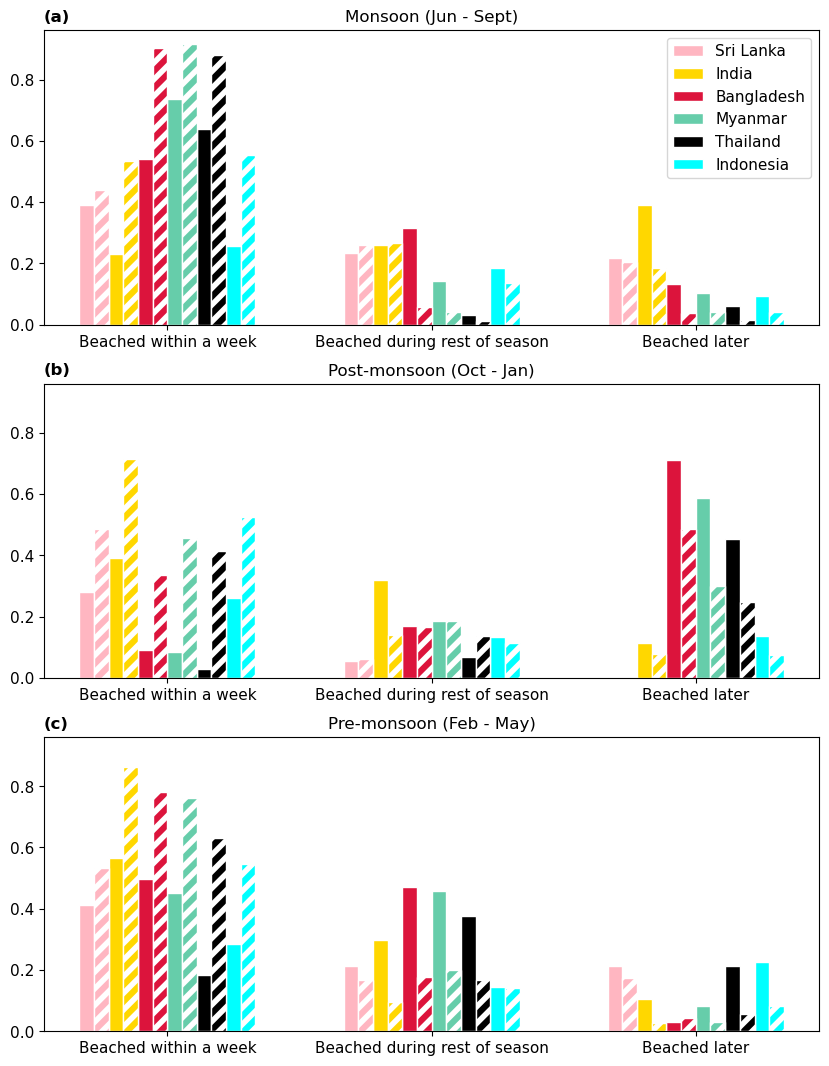

In [74]:
categories = ['Beached within a week', 'Beached during rest of season', 'Beached later']
bar_width = 0.05
space = 1.0  # Space between categories
plt.rcParams['hatch.linewidth'] = 4.0

# Create figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 13), sharey=True)

x_positions = np.arange(len(categories)) * 18 * bar_width + space
labels = ['Sri Lanka', 'India', 'Bangladesh', 'Myanmar', 'Thailand', 'Indonesia']
# print(np.shape(x_positions))

# Subplot 1
axes[0].bar(x_positions[0] - 5.5 * bar_width, week_beached_mon_values[0], width=bar_width, color='lightpink', edgecolor='white', label=labels[0])
axes[0].bar(x_positions[0] - 3.5 * bar_width, week_beached_mon_values[1], width=bar_width, color='gold', edgecolor='white', label=labels[1])
axes[0].bar(x_positions[0] - 1.5 * bar_width, week_beached_mon_values[2], width=bar_width, color='crimson', edgecolor='white', label=labels[2])
axes[0].bar(x_positions[0] + 0.5 * bar_width, week_beached_mon_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white', label=labels[3])
axes[0].bar(x_positions[0] + 2.5 * bar_width, week_beached_mon_values[4], width=bar_width, color='k', edgecolor='white', label=labels[4])
axes[0].bar(x_positions[0] + 4.5 * bar_width, week_beached_mon_values[5], width=bar_width, color='cyan', edgecolor='white', label=labels[5])
axes[0].bar(x_positions[1] - 5.5 * bar_width, season_beached_mon_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[0].bar(x_positions[1] - 3.5 * bar_width, season_beached_mon_values[1], width=bar_width, color='gold', edgecolor='white')
axes[0].bar(x_positions[1] - 1.5 * bar_width, season_beached_mon_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[0].bar(x_positions[1] + 0.5 * bar_width, season_beached_mon_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[0].bar(x_positions[1] + 2.5 * bar_width, season_beached_mon_values[4], width=bar_width, color='k', edgecolor='white')
axes[0].bar(x_positions[1] + 4.5 * bar_width, season_beached_mon_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[0].bar(x_positions[2] - 5.5 * bar_width, later_beached_mon_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[0].bar(x_positions[2] - 3.5 * bar_width, later_beached_mon_values[1], width=bar_width, color='gold', edgecolor='white')
axes[0].bar(x_positions[2] - 1.5 * bar_width, later_beached_mon_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[0].bar(x_positions[2] + 0.5 * bar_width, later_beached_mon_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[0].bar(x_positions[2] + 2.5 * bar_width, later_beached_mon_values[4], width=bar_width, color='k', edgecolor='white')
axes[0].bar(x_positions[2] + 4.5 * bar_width, later_beached_mon_values[5], width=bar_width, color='cyan', edgecolor='white')

axes[0].bar(x_positions[0] - 4.5 * bar_width, week_beached_mon_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] - 2.5 * bar_width, week_beached_mon_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] - 0.5 * bar_width, week_beached_mon_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] + 1.5 * bar_width, week_beached_mon_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] + 3.5 * bar_width, week_beached_mon_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] + 5.5 * bar_width, week_beached_mon_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] - 4.5 * bar_width, season_beached_mon_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] - 2.5 * bar_width, season_beached_mon_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] - 0.5 * bar_width, season_beached_mon_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] + 1.5 * bar_width, season_beached_mon_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] + 3.5 * bar_width, season_beached_mon_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] + 5.5 * bar_width, season_beached_mon_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] - 4.5 * bar_width, later_beached_mon_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] - 2.5 * bar_width, later_beached_mon_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] - 0.5 * bar_width, later_beached_mon_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] + 1.5 * bar_width, later_beached_mon_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] + 3.5 * bar_width, later_beached_mon_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] + 5.5 * bar_width, later_beached_mon_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')

axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(categories, fontsize=11)
axes[0].set_title("Monsoon (Jun - Sept)", fontsize=12)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
for label in axes[0].get_yticklabels():
    label.set_fontsize(11)
axes[0].legend(fontsize=11)

# Subplot 2
axes[1].bar(x_positions[0] - 5.5 * bar_width, week_beached_post_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[1].bar(x_positions[0] - 3.5 * bar_width, week_beached_post_values[1], width=bar_width, color='gold', edgecolor='white')
axes[1].bar(x_positions[0] - 1.5 * bar_width, week_beached_post_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[1].bar(x_positions[0] + 0.5 * bar_width, week_beached_post_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[1].bar(x_positions[0] + 2.5 * bar_width, week_beached_post_values[4], width=bar_width, color='k', edgecolor='white')
axes[1].bar(x_positions[0] + 4.5 * bar_width, week_beached_post_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[1].bar(x_positions[1] - 5.5 * bar_width, season_beached_post_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[1].bar(x_positions[1] - 3.5 * bar_width, season_beached_post_values[1], width=bar_width, color='gold', edgecolor='white')
axes[1].bar(x_positions[1] - 1.5 * bar_width, season_beached_post_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[1].bar(x_positions[1] + 0.5 * bar_width, season_beached_post_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[1].bar(x_positions[1] + 2.5 * bar_width, season_beached_post_values[4], width=bar_width, color='k', edgecolor='white')
axes[1].bar(x_positions[1] + 4.5 * bar_width, season_beached_post_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[1].bar(x_positions[2] - 5.5 * bar_width, later_beached_post_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[1].bar(x_positions[2] - 3.5 * bar_width, later_beached_post_values[1], width=bar_width, color='gold', edgecolor='white')
axes[1].bar(x_positions[2] - 1.5 * bar_width, later_beached_post_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[1].bar(x_positions[2] + 0.5 * bar_width, later_beached_post_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[1].bar(x_positions[2] + 2.5 * bar_width, later_beached_post_values[4], width=bar_width, color='k', edgecolor='white')
axes[1].bar(x_positions[2] + 4.5 * bar_width, later_beached_post_values[5], width=bar_width, color='cyan', edgecolor='white')

axes[1].bar(x_positions[0] - 4.5 * bar_width, week_beached_post_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] - 2.5 * bar_width, week_beached_post_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] - 0.5 * bar_width, week_beached_post_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] + 1.5 * bar_width, week_beached_post_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] + 3.5 * bar_width, week_beached_post_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] + 5.5 * bar_width, week_beached_post_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] - 4.5 * bar_width, season_beached_post_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] - 2.5 * bar_width, season_beached_post_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] - 0.5 * bar_width, season_beached_post_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] + 1.5 * bar_width, season_beached_post_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] + 3.5 * bar_width, season_beached_post_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] + 5.5 * bar_width, season_beached_post_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] - 4.5 * bar_width, later_beached_post_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] - 2.5 * bar_width, later_beached_post_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] - 0.5 * bar_width, later_beached_post_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] + 1.5 * bar_width, later_beached_post_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] + 3.5 * bar_width, later_beached_post_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] + 5.5 * bar_width, later_beached_post_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')

axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(categories, fontsize=11)
axes[1].set_title("Post-monsoon (Oct - Jan)", fontsize=12)
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
for label in axes[1].get_yticklabels():
    label.set_fontsize(11)
# axes[1].legend()

# Subplot 3
axes[2].bar(x_positions[0] - 5.5 * bar_width, week_beached_pre_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[2].bar(x_positions[0] - 3.5 * bar_width, week_beached_pre_values[1], width=bar_width, color='gold', edgecolor='white')
axes[2].bar(x_positions[0] - 1.5 * bar_width, week_beached_pre_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[2].bar(x_positions[0] + 0.5 * bar_width, week_beached_pre_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[2].bar(x_positions[0] + 2.5 * bar_width, week_beached_pre_values[4], width=bar_width, color='k', edgecolor='white')
axes[2].bar(x_positions[0] + 4.5 * bar_width, week_beached_pre_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[2].bar(x_positions[1] - 5.5 * bar_width, season_beached_pre_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[2].bar(x_positions[1] - 3.5 * bar_width, season_beached_pre_values[1], width=bar_width, color='gold', edgecolor='white')
axes[2].bar(x_positions[1] - 1.5 * bar_width, season_beached_pre_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[2].bar(x_positions[1] + 0.5 * bar_width, season_beached_pre_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[2].bar(x_positions[1] + 2.5 * bar_width, season_beached_pre_values[4], width=bar_width, color='k', edgecolor='white')
axes[2].bar(x_positions[1] + 4.5 * bar_width, season_beached_pre_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[2].bar(x_positions[2] - 5.5 * bar_width, later_beached_pre_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[2].bar(x_positions[2] - 3.5 * bar_width, later_beached_pre_values[1], width=bar_width, color='gold', edgecolor='white')
axes[2].bar(x_positions[2] - 1.5 * bar_width, later_beached_pre_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[2].bar(x_positions[2] + 0.5 * bar_width, later_beached_pre_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[2].bar(x_positions[2] + 2.5 * bar_width, later_beached_pre_values[4], width=bar_width, color='k', edgecolor='white')
axes[2].bar(x_positions[2] + 4.5 * bar_width, later_beached_pre_values[5], width=bar_width, color='cyan', edgecolor='white')

axes[2].bar(x_positions[0] - 4.5 * bar_width, week_beached_pre_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] - 2.5 * bar_width, week_beached_pre_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] - 0.5 * bar_width, week_beached_pre_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] + 1.5 * bar_width, week_beached_pre_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] + 3.5 * bar_width, week_beached_pre_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] + 5.5 * bar_width, week_beached_pre_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] - 4.5 * bar_width, season_beached_pre_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] - 2.5 * bar_width, season_beached_pre_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] - 0.5 * bar_width, season_beached_pre_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] + 1.5 * bar_width, season_beached_pre_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] + 3.5 * bar_width, season_beached_pre_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] + 5.5 * bar_width, season_beached_pre_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] - 4.5 * bar_width, later_beached_pre_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] - 2.5 * bar_width, later_beached_pre_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] - 0.5 * bar_width, later_beached_pre_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] + 1.5 * bar_width, later_beached_pre_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] + 3.5 * bar_width, later_beached_pre_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] + 5.5 * bar_width, later_beached_pre_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')

axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(categories,fontsize=11)
axes[2].set_title("Pre-monsoon (Feb - May)", fontsize=12)
axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
for label in axes[2].get_yticklabels():
    label.set_fontsize(11)
# axes[2].legend()

axes[0].text(0, 1.07, "(a)", transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[1].text(0, 1.07, "(b)", transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')
axes[2].text(0, 1.07, "(c)", transform=axes[2].transAxes, fontsize=12, fontweight='bold', va='top')

fig.savefig("/gpfs/home/rpe16nbu/projects/ocpp_mo1/plots/paper_data/when_beached", bbox_inches='tight')

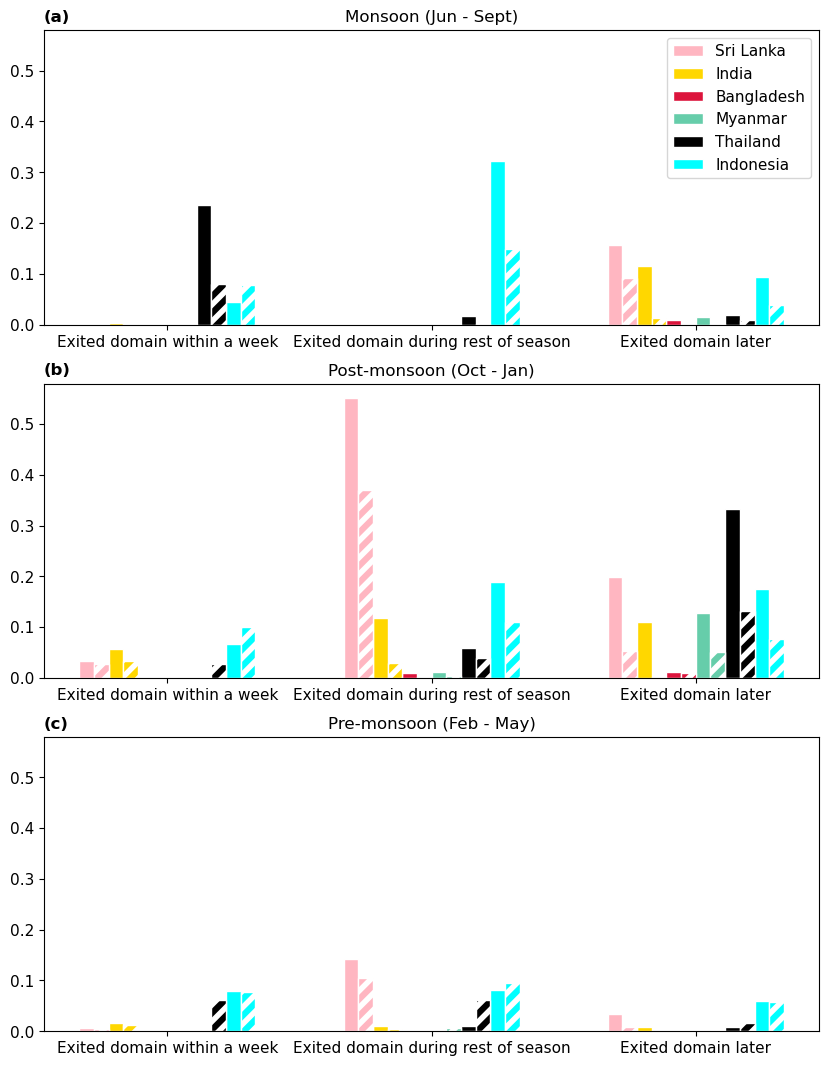

In [75]:
categories_escaped = ['Exited domain within a week', 'Exited domain during rest of season', 'Exited domain later']
bar_width = 0.05
space = 1.0  # Space between categories
plt.rcParams['hatch.linewidth'] = 4.0

# Create figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 13), sharey=True)

x_positions = np.arange(len(categories_escaped)) * 18 * bar_width + space
labels = ['Sri Lanka', 'India', 'Bangladesh', 'Myanmar', 'Thailand', 'Indonesia']
# print(np.shape(x_positions))

# Subplot 1
axes[0].bar(x_positions[0] - 5.5 * bar_width, week_escaped_mon_values[0], width=bar_width, color='lightpink', edgecolor='white', label=labels[0])
axes[0].bar(x_positions[0] - 3.5 * bar_width, week_escaped_mon_values[1], width=bar_width, color='gold', edgecolor='white', label=labels[1])
axes[0].bar(x_positions[0] - 1.5 * bar_width, week_escaped_mon_values[2], width=bar_width, color='crimson', edgecolor='white', label=labels[2])
axes[0].bar(x_positions[0] + 0.5 * bar_width, week_escaped_mon_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white', label=labels[3])
axes[0].bar(x_positions[0] + 2.5 * bar_width, week_escaped_mon_values[4], width=bar_width, color='k', edgecolor='white', label=labels[4])
axes[0].bar(x_positions[0] + 4.5 * bar_width, week_escaped_mon_values[5], width=bar_width, color='cyan', edgecolor='white', label=labels[5])
axes[0].bar(x_positions[1] - 5.5 * bar_width, season_escaped_mon_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[0].bar(x_positions[1] - 3.5 * bar_width, season_escaped_mon_values[1], width=bar_width, color='gold', edgecolor='white')
axes[0].bar(x_positions[1] - 1.5 * bar_width, season_escaped_mon_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[0].bar(x_positions[1] + 0.5 * bar_width, season_escaped_mon_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[0].bar(x_positions[1] + 2.5 * bar_width, season_escaped_mon_values[4], width=bar_width, color='k', edgecolor='white')
axes[0].bar(x_positions[1] + 4.5 * bar_width, season_escaped_mon_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[0].bar(x_positions[2] - 5.5 * bar_width, later_escaped_mon_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[0].bar(x_positions[2] - 3.5 * bar_width, later_escaped_mon_values[1], width=bar_width, color='gold', edgecolor='white')
axes[0].bar(x_positions[2] - 1.5 * bar_width, later_escaped_mon_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[0].bar(x_positions[2] + 0.5 * bar_width, later_escaped_mon_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[0].bar(x_positions[2] + 2.5 * bar_width, later_escaped_mon_values[4], width=bar_width, color='k', edgecolor='white')
axes[0].bar(x_positions[2] + 4.5 * bar_width, later_escaped_mon_values[5], width=bar_width, color='cyan', edgecolor='white')

axes[0].bar(x_positions[0] - 4.5 * bar_width, week_escaped_mon_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] - 2.5 * bar_width, week_escaped_mon_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] - 0.5 * bar_width, week_escaped_mon_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] + 1.5 * bar_width, week_escaped_mon_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] + 3.5 * bar_width, week_escaped_mon_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[0].bar(x_positions[0] + 5.5 * bar_width, week_escaped_mon_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] - 4.5 * bar_width, season_escaped_mon_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] - 2.5 * bar_width, season_escaped_mon_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] - 0.5 * bar_width, season_escaped_mon_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] + 1.5 * bar_width, season_escaped_mon_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] + 3.5 * bar_width, season_escaped_mon_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[0].bar(x_positions[1] + 5.5 * bar_width, season_escaped_mon_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] - 4.5 * bar_width, later_escaped_mon_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] - 2.5 * bar_width, later_escaped_mon_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] - 0.5 * bar_width, later_escaped_mon_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] + 1.5 * bar_width, later_escaped_mon_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] + 3.5 * bar_width, later_escaped_mon_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[0].bar(x_positions[2] + 5.5 * bar_width, later_escaped_mon_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')

axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(categories_escaped, fontsize=11)
axes[0].set_title("Monsoon (Jun - Sept)", fontsize=12)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
for label in axes[0].get_yticklabels():
    label.set_fontsize(11)
axes[0].legend(fontsize=11)

# Subplot 2
axes[1].bar(x_positions[0] - 5.5 * bar_width, week_escaped_post_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[1].bar(x_positions[0] - 3.5 * bar_width, week_escaped_post_values[1], width=bar_width, color='gold', edgecolor='white')
axes[1].bar(x_positions[0] - 1.5 * bar_width, week_escaped_post_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[1].bar(x_positions[0] + 0.5 * bar_width, week_escaped_post_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[1].bar(x_positions[0] + 2.5 * bar_width, week_escaped_post_values[4], width=bar_width, color='k', edgecolor='white')
axes[1].bar(x_positions[0] + 4.5 * bar_width, week_escaped_post_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[1].bar(x_positions[1] - 5.5 * bar_width, season_escaped_post_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[1].bar(x_positions[1] - 3.5 * bar_width, season_escaped_post_values[1], width=bar_width, color='gold', edgecolor='white')
axes[1].bar(x_positions[1] - 1.5 * bar_width, season_escaped_post_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[1].bar(x_positions[1] + 0.5 * bar_width, season_escaped_post_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[1].bar(x_positions[1] + 2.5 * bar_width, season_escaped_post_values[4], width=bar_width, color='k', edgecolor='white')
axes[1].bar(x_positions[1] + 4.5 * bar_width, season_escaped_post_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[1].bar(x_positions[2] - 5.5 * bar_width, later_escaped_post_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[1].bar(x_positions[2] - 3.5 * bar_width, later_escaped_post_values[1], width=bar_width, color='gold', edgecolor='white')
axes[1].bar(x_positions[2] - 1.5 * bar_width, later_escaped_post_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[1].bar(x_positions[2] + 0.5 * bar_width, later_escaped_post_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[1].bar(x_positions[2] + 2.5 * bar_width, later_escaped_post_values[4], width=bar_width, color='k', edgecolor='white')
axes[1].bar(x_positions[2] + 4.5 * bar_width, later_escaped_post_values[5], width=bar_width, color='cyan', edgecolor='white')

axes[1].bar(x_positions[0] - 4.5 * bar_width, week_escaped_post_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] - 2.5 * bar_width, week_escaped_post_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] - 0.5 * bar_width, week_escaped_post_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] + 1.5 * bar_width, week_escaped_post_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] + 3.5 * bar_width, week_escaped_post_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[1].bar(x_positions[0] + 5.5 * bar_width, week_escaped_post_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] - 4.5 * bar_width, season_escaped_post_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] - 2.5 * bar_width, season_escaped_post_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] - 0.5 * bar_width, season_escaped_post_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] + 1.5 * bar_width, season_escaped_post_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] + 3.5 * bar_width, season_escaped_post_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[1].bar(x_positions[1] + 5.5 * bar_width, season_escaped_post_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] - 4.5 * bar_width, later_escaped_post_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] - 2.5 * bar_width, later_escaped_post_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] - 0.5 * bar_width, later_escaped_post_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] + 1.5 * bar_width, later_escaped_post_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] + 3.5 * bar_width, later_escaped_post_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[1].bar(x_positions[2] + 5.5 * bar_width, later_escaped_post_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')

axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(categories_escaped, fontsize=11)
axes[1].set_title("Post-monsoon (Oct - Jan)", fontsize=12)
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
for label in axes[1].get_yticklabels():
    label.set_fontsize(11)
# axes[1].legend()

# Subplot 3
axes[2].bar(x_positions[0] - 5.5 * bar_width, week_escaped_pre_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[2].bar(x_positions[0] - 3.5 * bar_width, week_escaped_pre_values[1], width=bar_width, color='gold', edgecolor='white')
axes[2].bar(x_positions[0] - 1.5 * bar_width, week_escaped_pre_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[2].bar(x_positions[0] + 0.5 * bar_width, week_escaped_pre_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[2].bar(x_positions[0] + 2.5 * bar_width, week_escaped_pre_values[4], width=bar_width, color='k', edgecolor='white')
axes[2].bar(x_positions[0] + 4.5 * bar_width, week_escaped_pre_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[2].bar(x_positions[1] - 5.5 * bar_width, season_escaped_pre_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[2].bar(x_positions[1] - 3.5 * bar_width, season_escaped_pre_values[1], width=bar_width, color='gold', edgecolor='white')
axes[2].bar(x_positions[1] - 1.5 * bar_width, season_escaped_pre_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[2].bar(x_positions[1] + 0.5 * bar_width, season_escaped_pre_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[2].bar(x_positions[1] + 2.5 * bar_width, season_escaped_pre_values[4], width=bar_width, color='k', edgecolor='white')
axes[2].bar(x_positions[1] + 4.5 * bar_width, season_escaped_pre_values[5], width=bar_width, color='cyan', edgecolor='white')
axes[2].bar(x_positions[2] - 5.5 * bar_width, later_escaped_pre_values[0], width=bar_width, color='lightpink', edgecolor='white')
axes[2].bar(x_positions[2] - 3.5 * bar_width, later_escaped_pre_values[1], width=bar_width, color='gold', edgecolor='white')
axes[2].bar(x_positions[2] - 1.5 * bar_width, later_escaped_pre_values[2], width=bar_width, color='crimson', edgecolor='white')
axes[2].bar(x_positions[2] + 0.5 * bar_width, later_escaped_pre_values[3], width=bar_width, color='mediumaquamarine', edgecolor='white')
axes[2].bar(x_positions[2] + 2.5 * bar_width, later_escaped_pre_values[4], width=bar_width, color='k', edgecolor='white')
axes[2].bar(x_positions[2] + 4.5 * bar_width, later_escaped_pre_values[5], width=bar_width, color='cyan', edgecolor='white')

axes[2].bar(x_positions[0] - 4.5 * bar_width, week_escaped_pre_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] - 2.5 * bar_width, week_escaped_pre_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] - 0.5 * bar_width, week_escaped_pre_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] + 1.5 * bar_width, week_escaped_pre_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] + 3.5 * bar_width, week_escaped_pre_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[2].bar(x_positions[0] + 5.5 * bar_width, week_escaped_pre_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] - 4.5 * bar_width, season_escaped_pre_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] - 2.5 * bar_width, season_escaped_pre_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] - 0.5 * bar_width, season_escaped_pre_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] + 1.5 * bar_width, season_escaped_pre_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] + 3.5 * bar_width, season_escaped_pre_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[2].bar(x_positions[1] + 5.5 * bar_width, season_escaped_pre_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] - 4.5 * bar_width, later_escaped_pre_valuesR[0], width=bar_width, color='lightpink', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] - 2.5 * bar_width, later_escaped_pre_valuesR[1], width=bar_width, color='gold', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] - 0.5 * bar_width, later_escaped_pre_valuesR[2], width=bar_width, color='crimson', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] + 1.5 * bar_width, later_escaped_pre_valuesR[3], width=bar_width, color='mediumaquamarine', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] + 3.5 * bar_width, later_escaped_pre_valuesR[4], width=bar_width, color='k', edgecolor='white', hatch='//')
axes[2].bar(x_positions[2] + 5.5 * bar_width, later_escaped_pre_valuesR[5], width=bar_width, color='cyan', edgecolor='white', hatch='//')

axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(categories_escaped, fontsize=11)
axes[2].set_title("Pre-monsoon (Feb - May)", fontsize=12)
axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
for label in axes[2].get_yticklabels():
    label.set_fontsize(11)
# axes[2].legend()

axes[0].text(0, 1.07, "(a)", transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[1].text(0, 1.07, "(b)", transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')
axes[2].text(0, 1.07, "(c)", transform=axes[2].transAxes, fontsize=12, fontweight='bold', va='top')

fig.savefig("/gpfs/home/rpe16nbu/projects/ocpp_mo1/plots/paper_data/when_escaped", bbox_inches='tight')
